<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>




*   Les sources de données originales se trouvent sur mon GoogleDisk personnel, car je travaille à partir de deux ordinateurs portables différents, de sorte que je dois pouvoir accéder au bloc-notes depuis n'importe où.
*   La plupart des opérations sont effectuées par la bibliothèque Pandas (y compris la somme des colonnes), mais pour certaines solutions, j'ai ajouté une alternative utilisant NumPy. J'ai séparé ce code par des # pour les commentaires afin qu'il ne soit pas exécuté directement dans le bloc courant.
*   Le bloc-notes contient beaucoup de commentaires et d'explications sur le code - cela fait partie de ma formation, où je crée des mémos sur l'utilisation de certaines constructions de code.
*   Certaines opérations sur les objets et les données ne sont pas nécessaires à l'analyse (par exemple, renommer des colonnes), mais servent à faciliter et à mieux comprendre les données.






<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [ ]:
# connexion à des sources de données sur Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Importation du fichier population.csv
file_path_population = '/content/drive/My Drive/Colab Notebooks/Source/population.csv'
population = pd.read_csv(file_path_population)

# Importation du fichier dispo_alimentaire.csv
file_path_dispo_alimentaire = '/content/drive/My Drive/Colab Notebooks/Source/dispo_alimentaire.csv'
dispo_alimentaire = pd.read_csv(file_path_dispo_alimentaire)

# Importation du fichier aide_alimentaire.csv
file_path_aide_alimentaire = '/content/drive/My Drive/Colab Notebooks/Source/aide_alimentaire.csv'
aide_alimentaire = pd.read_csv(file_path_aide_alimentaire)

# Importation du fichier sous_nutrition.csv
file_path_sous_nutrition = '/content/drive/My Drive/Colab Notebooks/Source/sous_nutrition.csv'
sous_nutrition = pd.read_csv(file_path_sous_nutrition)

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes

population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   object 
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 33.3+ KB


In [ ]:
# affichage les 5 premières lignes de la table
# méthode "head" affiche toujours 5 premières lignes du DataFrame

print(population.head())

          Zone  Année     Valeur
0  Afghanistan   2013  32269.589
1  Afghanistan   2014  33370.794
2  Afghanistan   2015  34413.603
3  Afghanistan   2016  35383.032
4  Afghanistan   2017  36296.113


In [ ]:
# harmoniser les unités et de multiplier la population par 1000
# multiplication de la colonne valeur par 1000

population['Valeur'] = population['Valeur'] * 1000
print(population.head())  # afficher les données modifiées

          Zone  Année      Valeur
0  Afghanistan   2013  32269589.0
1  Afghanistan   2014  33370794.0
2  Afghanistan   2015  34413603.0
3  Afghanistan   2016  35383032.0
4  Afghanistan   2017  36296113.0


In [ ]:
# changement du nom de la colonne Valeur par Population
# "inplace=True" change dans le DataFrame source en place et ne pas créer un nouvel objet DataFrame

population.rename(columns={'Valeur':'Population'}, inplace=True)

In [ ]:
# affichage les 5 premières lignes de la table pour voir les modifications

print(population.head())  # les données avec le nouveau nom de colonne

          Zone  Année  Population
0  Afghanistan   2013  32269589.0
1  Afghanistan   2014  33370794.0
2  Afghanistan   2015  34413603.0
3  Afghanistan   2016  35383032.0
4  Afghanistan   2017  36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [ ]:
# Afficher les dimensions du dataset - ce code indique le nombre
# de lignes et de colonnes dans le dataset dispo_alimentaire
# méthode "shape" renvoie un tuple contenant le nombre de lignes (shape[0])
# et de colonnes (shape[1]) du DataFrame "dispo_alimentaire"

print("Le tableau comporte {} observation(s) ou article(s)".format(dispo_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(dispo_alimentaire.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s)
Le tableau comporte 18 colonne(s)


In [ ]:
# Consulter le nombre de colonnes - affiche des info sur chaque colonne
# y compris les types de données et le nombre de valeurs non nulles

dispo_alimentaire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15605 entries, 0 to 15604
Data columns (total 18 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Zone                                                           15605 non-null  object 
 1   Produit                                                        15605 non-null  object 
 2   Origine                                                        15605 non-null  object 
 3   Aliments pour animaux                                          2720 non-null   float64
 4   Autres Utilisations                                            5496 non-null   float64
 5   Disponibilité alimentaire (Kcal/personne/jour)                 14241 non-null  float64
 6   Disponibilité alimentaire en quantité (kg/personne/an)         14015 non-null  float64
 7   Disponibilité de matière grasse en quantité (g/personne/jo

In [ ]:
# Affichage les 5 premières lignes de la table
# il est utile pour un bref examen des données

print(dispo_alimentaire.head())

          Zone                Produit   Origine  Aliments pour animaux  \
0  Afghanistan       Abats Comestible   animale                    NaN   
1  Afghanistan        Agrumes, Autres  vegetale                    NaN   
2  Afghanistan  Aliments pour enfants  vegetale                    NaN   
3  Afghanistan                 Ananas  vegetale                    NaN   
4  Afghanistan                Bananes  vegetale                    NaN   

   Autres Utilisations  Disponibilité alimentaire (Kcal/personne/jour)  \
0                  NaN                                             5.0   
1                  NaN                                             1.0   
2                  NaN                                             1.0   
3                  NaN                                             0.0   
4                  NaN                                             4.0   

   Disponibilité alimentaire en quantité (kg/personne/an)  \
0                                               1

In [ ]:
# remplacement des NaN dans le dataset par des 0
# méthode fillna() est utilisée pour remplir les valeurs NaN dans un DataFrame
# argument 0 indique par quoi toutes les valeurs NaN doivent être remplacées
# paramètre inplace=True indique que les modifications doivent être appliquées
# directement au DataFrame actuel (dispo_alimentaire)
# et ne pas créer un nouveau DataFrame modifié

dispo_alimentaire.fillna(0, inplace=True)

In [ ]:
# afficher les colonnes
print(dispo_alimentaire.columns)

Index(['Zone', 'Produit', 'Origine', 'Aliments pour animaux',
       'Autres Utilisations', 'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité intérieure', 'Exportations - Quantité',
       'Importations - Quantité', 'Nourriture', 'Pertes', 'Production',
       'Semences', 'Traitement', 'Variation de stock'],
      dtype='object')


In [ ]:
# multiplication de toutes les lignes contenant des milliers de tonnes en Kg

# création d'une liste de colonnes
tonnes = [
    'Aliments pour animaux',
    'Disponibilité intérieure',
    'Exportations - Quantité',
    'Importations - Quantité',
    'Nourriture',
    'Pertes',
    'Production',
    'Semences',
    'Traitement',
    'Variation de stock'
]

# multiplication les valeurs des colonnes de la liste par 1000000
# cycle 'for' est utilisé pour parcourir la liste des 'tonnes'
for column in tonnes:
    dispo_alimentaire[column] = dispo_alimentaire[column] * 1000000

# contrôle du résultat ( affichage des 5 premières lignes)
# spécifier une liste de colonnes pour éviter de lister les colonnes
print(dispo_alimentaire[tonnes].head())

   Aliments pour animaux  Disponibilité intérieure  Exportations - Quantité  \
0                    0.0                53000000.0                      0.0   
1                    0.0                41000000.0                2000000.0   
2                    0.0                 2000000.0                      0.0   
3                    0.0                       0.0                      0.0   
4                    0.0                82000000.0                      0.0   

   Importations - Quantité  Nourriture     Pertes  Production  Semences  \
0                      0.0  53000000.0        0.0  53000000.0       0.0   
1               40000000.0  39000000.0  2000000.0   3000000.0       0.0   
2                2000000.0   2000000.0        0.0         0.0       0.0   
3                      0.0         0.0        0.0         0.0       0.0   
4               82000000.0  82000000.0        0.0         0.0       0.0   

   Traitement  Variation de stock  
0         0.0                 0.0  
1 

In [ ]:
# affichage les 5 premières lignes de la table

print(dispo_alimentaire.head())  # afficher les données modifiées

          Zone                Produit   Origine  Aliments pour animaux  \
0  Afghanistan       Abats Comestible   animale                    0.0   
1  Afghanistan        Agrumes, Autres  vegetale                    0.0   
2  Afghanistan  Aliments pour enfants  vegetale                    0.0   
3  Afghanistan                 Ananas  vegetale                    0.0   
4  Afghanistan                Bananes  vegetale                    0.0   

   Autres Utilisations  Disponibilité alimentaire (Kcal/personne/jour)  \
0                  0.0                                             5.0   
1                  0.0                                             1.0   
2                  0.0                                             1.0   
3                  0.0                                             0.0   
4                  0.0                                             4.0   

   Disponibilité alimentaire en quantité (kg/personne/an)  \
0                                               1

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [ ]:
# afficher les dimensions du dataset - nombre de lignes et de colonnes

print("Le tableau comporte {} observation(s) ou article(s)".format(aide_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(aide_alimentaire.shape[1]))

Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [ ]:
# consulter le nombre de colonnes + cette méthode montre aussi des infos sur
# les types de données dans chaque colonne et la présence de valeurs non nulles

aide_alimentaire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Pays bénéficiaire  1475 non-null   object
 1   Année              1475 non-null   int64 
 2   Produit            1475 non-null   object
 3   Valeur             1475 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.2+ KB


In [ ]:
# affichage les 5 premières lignes de la table

print(aide_alimentaire.head())

  Pays bénéficiaire  Année              Produit  Valeur
0       Afghanistan   2013  Autres non-céréales     682
1       Afghanistan   2014  Autres non-céréales     335
2       Afghanistan   2013         Blé et Farin   39224
3       Afghanistan   2014         Blé et Farin   15160
4       Afghanistan   2013             Céréales   40504


In [ ]:
# changement du nom de la colonne Pays bénéficiaire par Zone
# pour unifier les noms de colonnes

aide_alimentaire.rename(columns={'Pays bénéficiaire': 'Zone'}, inplace=True)

In [ ]:
# multiplication de la colonne Aide_alimentaire - des tonnes par 1000 pour avoir des kg
aide_alimentaire['Valeur'] = aide_alimentaire['Valeur'] * 1000

In [ ]:
#Affichage les 5 premières lignes de la table

print(aide_alimentaire.head())

          Zone  Année              Produit    Valeur
0  Afghanistan   2013  Autres non-céréales    682000
1  Afghanistan   2014  Autres non-céréales    335000
2  Afghanistan   2013         Blé et Farin  39224000
3  Afghanistan   2014         Blé et Farin  15160000
4  Afghanistan   2013             Céréales  40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [ ]:
# Afficher les dimensions du dataset

print("Le tableau comporte {} observation(s) ou article(s)".format(sous_nutrition.shape[0]))
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))

Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [ ]:
# Consulter le nombre de colonnes

sous_nutrition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Zone    1218 non-null   object
 1   Année   1218 non-null   object
 2   Valeur  624 non-null    object
dtypes: object(3)
memory usage: 28.7+ KB


In [ ]:
# Afficher les 5 premières lignes de la table

print(sous_nutrition.head())

          Zone      Année Valeur
0  Afghanistan  2012-2014    8.6
1  Afghanistan  2013-2015    8.8
2  Afghanistan  2014-2016    8.9
3  Afghanistan  2015-2017    9.7
4  Afghanistan  2016-2018   10.5


In [ ]:
# Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'], errors='coerce')

# Puis remplacement des NaN en 0 : la méthode fillna() remplace
# toutes les valeurs NaN de la colonne Valeur par 0

sous_nutrition['Valeur'] = sous_nutrition['Valeur'].fillna(0)

In [ ]:
# changement du nom de la colonne Valeur par sous_nutrition

sous_nutrition.rename(columns={'Valeur': 'sous_nutrition'}, inplace=True)

In [ ]:
# Multiplication de la colonne sous_nutrition par 1000000

sous_nutrition['sous_nutrition'] = sous_nutrition['sous_nutrition'] * 1000000

In [ ]:
# Afficher les 5 premières lignes de la table

print(sous_nutrition.head())

          Zone      Année  sous_nutrition
0  Afghanistan  2012-2014       8600000.0
1  Afghanistan  2013-2015       8800000.0
2  Afghanistan  2014-2016       8900000.0
3  Afghanistan  2015-2017       9700000.0
4  Afghanistan  2016-2018      10500000.0


In [ ]:
# Diviser la colonne "Année" en 3 - diviser la période de 3 ans en 3 colonnes d'un an chacune
# La fonction split() est utilisée avec expand=True pour que chaque partie de
# la ligne divisée devienne une colonne distincte
sous_nutrition[['Année1', 'Année3']] = sous_nutrition['Année'].str.split('-', expand=True)

# Convertir ces colonnes en type numérique pour les calculs ultérieurs
sous_nutrition['Année1'] = sous_nutrition['Année1'].astype(int)
sous_nutrition['Année3'] = sous_nutrition['Année3'].astype(int)
sous_nutrition['Année2'] = sous_nutrition['Année1'] + 1

# suppression de la colonne d'origine Année
sous_nutrition.drop(columns=['Année'], inplace=True)

print(sous_nutrition)

             Zone  sous_nutrition  Année1  Année3  Année2
0     Afghanistan       8600000.0    2012    2014    2013
1     Afghanistan       8800000.0    2013    2015    2014
2     Afghanistan       8900000.0    2014    2016    2015
3     Afghanistan       9700000.0    2015    2017    2016
4     Afghanistan      10500000.0    2016    2018    2017
...           ...             ...     ...     ...     ...
1213     Zimbabwe             0.0    2013    2015    2014
1214     Zimbabwe             0.0    2014    2016    2015
1215     Zimbabwe             0.0    2015    2017    2016
1216     Zimbabwe             0.0    2016    2018    2017
1217     Zimbabwe             0.0    2017    2019    2018

[1218 rows x 5 columns]


In [ ]:
# Filtrer les données par les lignes où 2017 est inclus, créer un nouveau dataframe

sous_nutrition_2017 = sous_nutrition[
    (sous_nutrition['Année1'] == 2017) |
    (sous_nutrition['Année2'] == 2017) |
    (sous_nutrition['Année3'] == 2017)
]

# Afficher les résultats après les modifications
print(sous_nutrition_2017.head(10))

              Zone  sous_nutrition  Année1  Année3  Année2
3      Afghanistan       9700000.0    2015    2017    2016
4      Afghanistan      10500000.0    2016    2018    2017
5      Afghanistan      11100000.0    2017    2019    2018
9   Afrique du Sud       3000000.0    2015    2017    2016
10  Afrique du Sud       3100000.0    2016    2018    2017
11  Afrique du Sud       3300000.0    2017    2019    2018
15         Albanie        100000.0    2015    2017    2016
16         Albanie        100000.0    2016    2018    2017
17         Albanie        100000.0    2017    2019    2018
21         Algérie       1300000.0    2015    2017    2016


In [ ]:
# nunique() compte le nombre de valeurs uniques dans la colonne « Zone »
unique_countries_count = sous_nutrition_2017['Zone'].nunique()
print(unique_countries_count)

203


In [ ]:
# regrouper les données par pays et calculer la valeur moyenne
sous_nutrition_grouped = sous_nutrition_2017.groupby('Zone', as_index=False)['sous_nutrition'].mean()

# Отображение значений в столбце 'sous_nutrition' без научной нотации
pd.options.display.float_format = '{:.0f}'.format

# afficher les résultats après les modifications
print(sous_nutrition_grouped.head())

             Zone  sous_nutrition
0     Afghanistan        10433333
1  Afrique du Sud         3133333
2         Albanie          100000
3         Algérie         1266667
4       Allemagne               0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [ ]:
# Faire une jointure = la table "population" et la table "sous_nutrition", en ciblant l'année 2017
# joindre les tableaux par la clé 'Zone' et filtrer les données pour 2017

# Filtrage des données dans la population pour 2017
# Le double signe égal est utilisé pour vérifier si deux valeurs sont égales
population_2017 = population[population['Année'] == 2017]

# Fusionner les tables filtrés par la colonne "Zone"
# remarque - la table "sous_nutrition_2017" a déjà été créée précédemment
# df.merge() fusionne 2 DataFrames par colonnes clés (analogue à une jointure SQL)
# how='inner' paramètre définissant le type de fusion, le résultat ne contiendra
# que les lignes pour lesquelles il y a une correspondance dans les deux tables
pop_sousnutr_2017 = pd.merge(sous_nutrition_grouped, population_2017, on='Zone', how='inner')

# Affichage du résultat de la fusion de deux tables
print(pop_sousnutr_2017)

                      Zone  sous_nutrition  Année  Population
0              Afghanistan        10433333   2017    36296113
1           Afrique du Sud         3133333   2017    57009756
2                  Albanie          100000   2017     2884169
3                  Algérie         1266667   2017    41389189
4                Allemagne               0   2017    82658409
..                     ...             ...    ...         ...
198  États-Unis d'Amérique               0   2017   325084756
199               Éthiopie        21300000   2017   106399924
200              Îles Cook               0   2017       17507
201          Îles Marshall               0   2017       58058
202           Îles Salomon               0   2017      636039

[203 rows x 4 columns]


In [ ]:
# Sélectionner uniquement les colonnes nécessaires à l'analyse
print(pop_sousnutr_2017[['Zone', 'Population', 'sous_nutrition']])

                      Zone  Population  sous_nutrition
0              Afghanistan    36296113        10433333
1           Afrique du Sud    57009756         3133333
2                  Albanie     2884169          100000
3                  Algérie    41389189         1266667
4                Allemagne    82658409               0
..                     ...         ...             ...
198  États-Unis d'Amérique   325084756               0
199               Éthiopie   106399924        21300000
200              Îles Cook       17507               0
201          Îles Marshall       58058               0
202           Îles Salomon      636039               0

[203 rows x 3 columns]


In [ ]:
# Calcul et affichage du nombre de personnes en état de sous nutrition
# l'opération de division entre colonnes donne une proportion (sous forme décimale) !
# la multiplication par 100 convertit une valeur décimale en pourcentage
pop_sousnutr_2017['Proportion'] = (pop_sousnutr_2017['sous_nutrition'] /
                                   pop_sousnutr_2017['Population']) * 100

# affichage des résultats
print(pop_sousnutr_2017[['Zone', 'Population', 'Proportion']])

                      Zone  Population  Proportion
0              Afghanistan    36296113          29
1           Afrique du Sud    57009756           5
2                  Albanie     2884169           3
3                  Algérie    41389189           3
4                Allemagne    82658409           0
..                     ...         ...         ...
198  États-Unis d'Amérique   325084756           0
199               Éthiopie   106399924          20
200              Îles Cook       17507           0
201          Îles Marshall       58058           0
202           Îles Salomon      636039           0

[203 rows x 3 columns]


In [ ]:
# Affichage des résultats pour répondre à la diapositive n° 1
# Montrer les 20 pays où le pourcentage de sous-alimentation est le plus élevé

# Trier les données par ordre décroissant de "Proportion" et sélectionner les 20 premières lignes
#  sort_values(by='Proportion', ascending=False) - trie le DataFrame par 'Proportion' de la valeur la plus élevée à la valeur la plus basse
# head(20) renvoie les 20 premières lignes du DataFrame trié
top_20_sousnutr = pop_sousnutr_2017.sort_values(by='Proportion', ascending=False).head(20)

# Résultats pour les 20 pays où la proportion de sous-alimentation est la plus élevée
print(top_20_sousnutr[['Zone', 'Population', 'Proportion']])


                                           Zone  Population  Proportion
72                                        Haïti    10982366          48
151  République populaire démocratique de Corée    25429825          47
99                                   Madagascar    25570512          41
95                                      Libéria     4702226          38
174                                       Tchad    15016753          38
91                                      Lesotho     2091534          37
143                                      Rwanda    11980961          35
112                                  Mozambique    28649018          33
177                                 Timor-Leste     1243258          32
0                                   Afghanistan    36296113          29
44                                        Congo     5110695          27
161                                Sierra Leone     7488423          27
189      Venezuela (République bolivarienne du)    29402484     

In [ ]:
pop_sousnutr_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Zone            203 non-null    object 
 1   sous_nutrition  203 non-null    float64
 2   Année           203 non-null    int64  
 3   Population      203 non-null    float64
 4   Proportion      203 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 8.1+ KB


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [ ]:
# Combien mange en moyenne un être humain ? L'apport calorique quotidien moyen est d'environ 2 000 calories pour les femmes et 2 500 pour les hommes,
# mais il peut varier en fonction de l'âge, du niveau d'activité physique et d'autres facteurs.  Source => Organisation mondiale de la santé (OMS)

# la moyenne entre l'apport calorique d'un homme et d'une femme est de 2250 AVEC NUMPY

# Créer une matrice de données
values = np.array([2000, 2500])

# Calculer la moyenne arithmétique
besoin_kcal_quotidien = np.mean(values)

# Afficher le résultat du calcul
besoin_kcal_quotidien

2250.0

In [ ]:
# jointure "population" et "dispo_alimentaire" afin d'ajouter dans ce dernier la population

# filtrer la population de chaque pays en 2017
population_2017 = population[population['Année'] == 2017]

# enrichir "dispo alimentaire" en ajoutant la population de chaque pays en 2017
dispo_alimentaire_2017 = pd.merge(dispo_alimentaire, population_2017, on='Zone', how='inner')

# Affichage du résultat de la fusion de deux tables
print(dispo_alimentaire_2017)

               Zone                Produit   Origine  Aliments pour animaux  \
0       Afghanistan       Abats Comestible   animale                      0   
1       Afghanistan        Agrumes, Autres  vegetale                      0   
2       Afghanistan  Aliments pour enfants  vegetale                      0   
3       Afghanistan                 Ananas  vegetale                      0   
4       Afghanistan                Bananes  vegetale                      0   
...             ...                    ...       ...                    ...   
15411  Îles Salomon       Viande de Suides   animale                      0   
15412  Îles Salomon    Viande de Volailles   animale                      0   
15413  Îles Salomon          Viande, Autre   animale                      0   
15414  Îles Salomon                    Vin  vegetale                      0   
15415  Îles Salomon         Épices, Autres  vegetale                      0   

       Autres Utilisations  Disponibilité alimentai

In [ ]:
#Affichage du nouveau dataframe
dispo_alimentaire_2017.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population
0,Afghanistan,Abats Comestible,animale,0,0,5,2,0,1,53000000,0,0,53000000,0,53000000,0,0,0,2017,36296113
1,Afghanistan,"Agrumes, Autres",vegetale,0,0,1,1,0,0,41000000,2000000,40000000,39000000,2000000,3000000,0,0,0,2017,36296113
2,Afghanistan,Aliments pour enfants,vegetale,0,0,1,0,0,0,2000000,0,2000000,2000000,0,0,0,0,0,2017,36296113
3,Afghanistan,Ananas,vegetale,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2017,36296113
4,Afghanistan,Bananes,vegetale,0,0,4,3,0,0,82000000,0,82000000,82000000,0,0,0,0,0,2017,36296113


In [ ]:
# Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
# SI JE COMPRENDS BIEN - calculer le nombre de calories disponibles pour chaque pays en 2017
dispo_alimentaire_2017['dispo_kcal'] = dispo_alimentaire_2017['Disponibilité alimentaire (Kcal/personne/jour)'] * dispo_alimentaire_2017['Population']

In [ ]:
#Calcul du nombre d'humains pouvant être nourris

# Calculer le besoin calorique ANNUEL
besoin_kcal_annuel = besoin_kcal_quotidien * 365

# Calculer le nombre théorique de personnes pouvant être nourries
dispo_alimentaire_2017['nombre_théorique'] = dispo_alimentaire_2017['dispo_kcal'] / besoin_kcal_annuel

# Regroupement des données par pays et synthèse des valeurs théoriques
#  .groupby('Zone') - regroupe les résultats par colonne
# agg() est utilisé pour déterminer les fonctions agrégées à appliquer à chaque colonne
# .reset_index() - convertit le résultat de l'agrégation en un DataFrame normal, où chaque groupe (dans ce cas, chaque pays) devient une ligne distincte

dispo_alimentaire_2017_grouped = dispo_alimentaire_2017.groupby('Zone').agg({
    'nombre_théorique': 'sum',   # Résumez le nombre théorique de personnes pour chaque pays
    'Population': 'first'        # Prendre la première valeur de la population, puisque toutes les valeurs sont identiques
}).reset_index()

# Arrondir les valeurs de la colonne 'nombre_théorique_total' en nombres entiers
dispo_alimentaire_2017_grouped['nombre_théorique'] = dispo_alimentaire_2017_grouped['nombre_théorique'].round(0)

# Trier le DataFrame par la colonne 'nombre_théorique_total' dans l'ordre croissant
dispo_alimentaire_2017_grouped = dispo_alimentaire_2017_grouped.sort_values('nombre_théorique', ascending=True)

# Afficher le DataFrame mis à jour pour vérification
print(dispo_alimentaire_2017_grouped[['Zone', 'Population', 'nombre_théorique']].head(30))

                                Zone  Population  nombre_théorique
134             Saint-Kitts-et-Nevis       52045               158
18                          Bermudes       63049               205
46                         Dominique       71458               255
6                 Antigua-et-Barbuda       95426               281
58                           Grenade      110874               330
135  Saint-Vincent-et-les Grenadines      109827               397
82                          Kiribati      114158               423
136                     Sainte-Lucie      180954               570
138             Sao Tomé-et-Principe      207089               605
137                            Samoa      195352               703
110               Nouvelle-Calédonie      277150               963
122              Polynésie française      276102               983
160                          Vanuatu      285510               985
15                           Barbade      286232              

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [ ]:
# Transfert des données avec les végétaux dans un nouveau dataframe
# filtre le DataFrame original, en ne laissant que les lignes dont la colonne Origine est "vegetale"
# .loc[] permet de sélectionner des données en fonction du nom des colonnes
dispo_alimentaire_2017_vegetale = dispo_alimentaire_2017.loc[dispo_alimentaire_2017['Origine'] == 'vegetale']

In [ ]:
#Calcul du nombre de kcal disponible pour les végétaux
dispo_alimentaire_2017_vegetale.loc[:, 'nombre_théorique'] = dispo_alimentaire_2017_vegetale['dispo_kcal'] / besoin_kcal_annuel

In [ ]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
dispo_alimentaire_2017_vegetale_grouped = dispo_alimentaire_2017_vegetale.groupby('Zone').agg({
    'nombre_théorique': 'sum',   # Résumez le nombre théorique de personnes pour chaque pays
    'Population': 'first'        # Prendre la première valeur de la population, puisque toutes les valeurs sont identiques
}).reset_index()

# Arrondir les valeurs de la colonne 'nombre_théorique_total' en nombres entiers
dispo_alimentaire_2017_vegetale_grouped['nombre_théorique'] = dispo_alimentaire_2017_vegetale_grouped['nombre_théorique'].round(0)

# Trier le DataFrame par la colonne 'nombre_théorique_total' dans l'ordre croissant
dispo_alimentaire_2017_vegetale_grouped = dispo_alimentaire_2017_vegetale_grouped.sort_values('nombre_théorique', ascending=True)

# Afficher le DataFrame mis à jour pour vérification
print(dispo_alimentaire_2017_vegetale_grouped[['Zone', 'Population', 'nombre_théorique']].head(30))

                                Zone  Population  nombre_théorique
134             Saint-Kitts-et-Nevis       52045               115
18                          Bermudes       63049               143
6                 Antigua-et-Barbuda       95426               190
46                         Dominique       71458               205
58                           Grenade      110874               252
135  Saint-Vincent-et-les Grenadines      109827               318
82                          Kiribati      114158               373
136                     Sainte-Lucie      180954               401
137                            Samoa      195352               509
138             Sao Tomé-et-Principe      207089               558
122              Polynésie française      276102               693
110               Nouvelle-Calédonie      277150               696
73                           Islande      334393               767
15                           Barbade      286232              

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

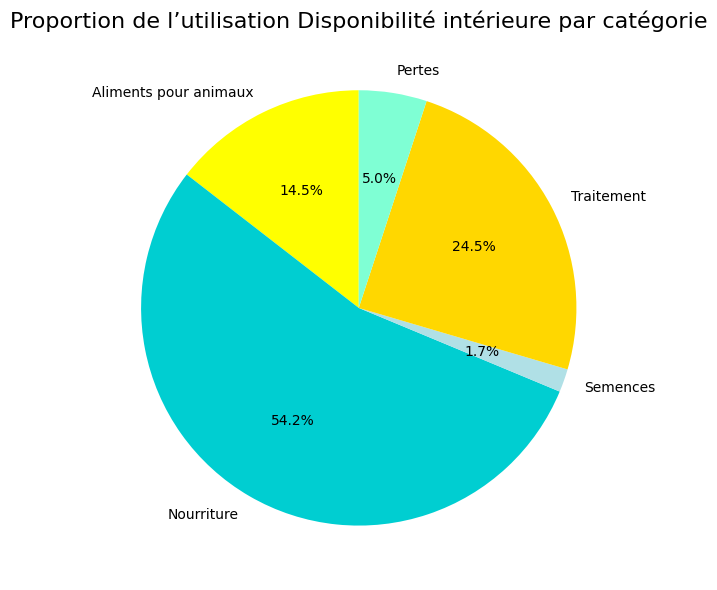

In [ ]:
# calculer la 'Disponibilité intérieure' estimée en utilisant la formule (été donnée dans les MEMO de la diapo 4)
dispo_alimentaire['calculated_dispo_interieure'] = (
    dispo_alimentaire['Production'] +
    dispo_alimentaire['Importations - Quantité'] -
    dispo_alimentaire['Exportations - Quantité'] +
    dispo_alimentaire['Variation de stock']
)

# calculer la 'Disponibilité intérieure' totale pour tous les pays présentés dans l’étude
total_disponibilite = dispo_alimentaire['calculated_dispo_interieure'].sum()

# calculer les proportions pour toutes les catégories - Aliments pour animaux, Nourriture, Semences, Traitement, Pertes
proportions = dispo_alimentaire[['Aliments pour animaux', 'Nourriture', 'Semences', 'Traitement', 'Pertes']].sum()

# construire un diagramme circulaire
plt.figure(figsize=(8, 6)) # créer une figure de 10x7 pouces
colors = ['Yellow', 'DarkTurquoise', 'PowderBlue', 'Gold', '#7FFFD4']

plt.pie(
    proportions, # des valeurs numériques pour le tracé du diagramme (taille des segments)
    labels=proportions.index, # des étiquettes pour ces valeurs qui sont affichées à côté des segments.
    autopct='%1.1f%%', # afficher des pourcentages pour chaque valeur et une décimale
    colors=colors, # utiliser une palette de couleurs prédéfinie pour les segments
    startangle=90)

# ajouter une légende pour plus d'informations
# plt.legend(title='Catégories', loc='upper left', bbox_to_anchor=(1, 1), fontsize=10, title_fontsize='11')

# paramétrage de l'en-tête
plt.title('Proportion de l’utilisation Disponibilité intérieure par catégorie', fontsize=16)

# assurer un placement optimal des éléments du graphique
plt.tight_layout()
plt.show()


#Création d'une liste avec toutes les variables


In [ ]:
# créer une liste de toutes les cultures céréales
produits_list = ['Blé', 'Riz (Eq Blanchi)', 'Orge', 'Maïs', 'Seigle', 'Avoine', 'Millet', 'Sorgho', 'Céréales, Autres']

# créer un dataframe avec les informations uniquement pour ces céréales
cereales_df = dispo_alimentaire[dispo_alimentaire['Produit'].isin(produits_list)]

print(cereales_df[['Produit', 'Aliments pour animaux', 'Nourriture']])

                Produit  Aliments pour animaux  Nourriture
7                   Blé                      0  4895000000
12     Céréales, Autres                      0           0
32                 Maïs              200000000    76000000
34               Millet                      0    12000000
40                 Orge              360000000    89000000
...                 ...                    ...         ...
15545  Céréales, Autres                      0           0
15568              Maïs                      0           0
15575              Orge                      0           0
15591  Riz (Eq Blanchi)                      0    36000000
15593            Sorgho                      0           0

[1497 rows x 3 columns]


In [ ]:
# regroupement du dataframe par la colonne Produit pour une meilleure lisibilité des données
# paramètre as_index=False signifie que le dataframe résultant aura la colonne Produit, plutôt que de l'utiliser comme index.
cereales_grouped = cereales_df.groupby('Produit', as_index=False)[['Aliments pour animaux', 'Nourriture']].sum()

# calculer la consommation totale de chaque céréale
cereales_grouped['Total'] = cereales_grouped['Aliments pour animaux'] + cereales_grouped['Nourriture']

# trier les données pour l'histogramme
cereales_grouped = cereales_grouped.sort_values(by='Total', ascending=False)

# ajouter des colonnes pour le calcul des proportions
cereales_grouped['Aliments pour animaux %'] = cereales_grouped['Aliments pour animaux']*100/cereales_grouped['Total']
cereales_grouped['Nourriture %'] = cereales_grouped['Nourriture']*100/cereales_grouped['Total']

# afficher le dataframe finalisé
print(cereales_grouped)

            Produit  Aliments pour animaux   Nourriture        Total  \
3              Maïs           546116000000 125184000000 671300000000   
1               Blé           129668000000 457824000000 587492000000   
6  Riz (Eq Blanchi)            33594000000 377286000000 410880000000   
5              Orge            92658000000   6794000000  99452000000   
8            Sorgho            24808000000  24153000000  48961000000   
4            Millet             3306000000  23040000000  26346000000   
2  Céréales, Autres            19035000000   5324000000  24359000000   
0            Avoine            16251000000   3903000000  20154000000   
7            Seigle             8099000000   5502000000  13601000000   

   Aliments pour animaux %  Nourriture %  
3                       81            19  
1                       22            78  
6                        8            92  
5                       93             7  
8                       51            49  
4                    

In [ ]:
# Affichage de la proportion d'alimentation humaine
# calculer la somme de la colonne « Nourriture » et trouver la part de la disponibilité totale
total_nourriture = cereales_grouped['Nourriture'].sum()
total_disponibilite = cereales_grouped[['Aliments pour animaux', 'Nourriture']].sum().sum()  # Общая доступность
proportion_nourriture = (total_nourriture / total_disponibilite) * 100
print(f'Proportion de Nourriture: {proportion_nourriture:.2f}%')


Proportion de Nourriture: 54.09%


In [ ]:
# Affichage de la proportion d'alimentation animale
total_animaux = cereales_grouped['Aliments pour animaux'].sum()
total_disponibilite = cereales_grouped[['Aliments pour animaux', 'Nourriture']].sum().sum()  # Общая доступность
proportion_animaux = (total_animaux / total_disponibilite) * 100
print(f'Proportion de Aliments pour animaux: {proportion_animaux:.2f}%')

Proportion de Aliments pour animaux: 45.91%


<ipython-input-53-e2984c8d2c26>:42: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(produits, rotation=45)


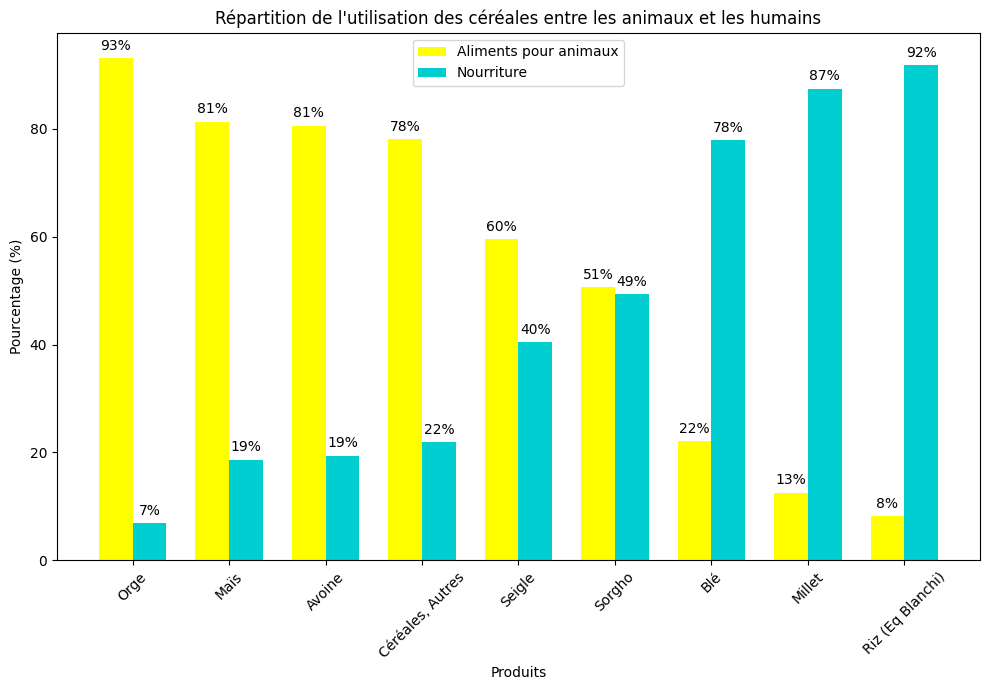

In [ ]:
# trier les données par colonne 'Aliments pour animaux %' pour améliorer la visualisation du graphique
cereales_grouped = cereales_grouped.sort_values(by='Aliments pour animaux %', ascending=False)

# attribuer des données variables pour simplifier la visualisation
produits = cereales_grouped['Produit']
aliments_animaux_percent = cereales_grouped['Aliments pour animaux %']
nourriture_percent = cereales_grouped['Nourriture %']
bar_width = 0.35  # la largeur de chaque colonne
index = np.arange(len(produits))  # crée un tableau contenant les positions de chaque colonne sur l'axe des X. La fonction np.arange() renvoie un tableau de nombres compris entre 0 et len(produits), où produits est une liste de noms de produits

# définir la forme et les axes du diagramme à barres + spécifier la taille du graphique
fig, ax = plt.subplots(figsize=(10, 7))

# créer un diagramme à barres, ou `bar_width`: la largeur de chaque colonne
# `aliments_animaux_percent` et `nourriture_percent`: c'est la hauteur des colonnes qui correspond aux pourcentages d'utilisation des cultures
bar1 = ax.bar(index, aliments_animaux_percent, bar_width, label='Aliments pour animaux', color='yellow') # index: positions sur l'axe X où les colonnes seront dessinées
bar2 = ax.bar(index + bar_width, nourriture_percent, bar_width, label='Nourriture', color='DarkTurquoise') # (index + bar_width) - décale la deuxième colonne de la largeur de la colonne afin qu'elles ne se recoupent pas

# ajouter des valeurs aux colonnes :

# la boucle for s'exécute sur les valeurs de deux listes (aliments_animaux_pourcentage et nourriture_pourcentage)
# la fonction zip() associe deux listes (aliments_animaux_percent et nourriture_percent) pour les traiter simultanément
# à chaque itération de la boucle, on obtient une paire de valeurs : le pourcentage d'animaux (v1) et le pourcentage d'humains (v2)
# enumerate() ajoute à ces paires l'indice 'i', qui indique le numéro d'itération (0, 1, 2, etc.). Il est nécessaire pour placer correctement les étiquettes sur le graphique (en fonction de la position des colonnes)
for i, (v1, v2) in enumerate(zip(aliments_animaux_percent, nourriture_percent)):
    ax.text(i, v1 + 1, f'{v1:.0f}%', ha='center', va='bottom')
    ax.text(i + bar_width, v2 + 1, f'{v2:.0f}%', ha='center', va='bottom')

# explication du code permettant d'ajouter des étiquettes aux colonnes :
# i: position sur l'axe des X, il s'agit de l'indice de colonne pour la valeur (animaux ou humains)
# v1 + 1: position sur l'axe des y (hauteur de la colonne et du texte au-dessus), et on ajoute 1 pour que le texte soit juste au-dessus du haut de la colonne
# f'{v1 :.0f}%': Mise en forme du texte. Cette syntaxe formate le nombre v1 comme un entier (.0f signifie qu'il n'y a pas de partie fractionnaire) et ajoute le symbole %
# ha='centre': l'alignement horizontal du texte spécifie que le texte sera aligné au centre de la colonne
# va='bottom': l'alignement vertical du texte signifie que le bas du texte sera aligné sur la coordonnée v1 + 1.

# ajouter des noms d'axes et de graphiques
ax.set_xlabel('Produits')
ax.set_ylabel('Pourcentage (%)')
ax.set_title('Répartition de l\'utilisation des céréales entre les animaux et les humains')

# ajouter les noms des cultures en tant qu'étiquettes sur l'axe X en les faisant pivoter de 45 degrés
ax.set_xticklabels(produits, rotation=45)

# placer les signes de l'axe des X au centre entre les deux colonnes pour chaque culture
ax.set_xticks(index + bar_width / 2)

# ajouter une légende pour interpréter les données
ax.legend()

# ajouter l'amélioration automatique du positionnement des éléments du graphique
plt.tight_layout()

# afficher le graphique
plt.show()

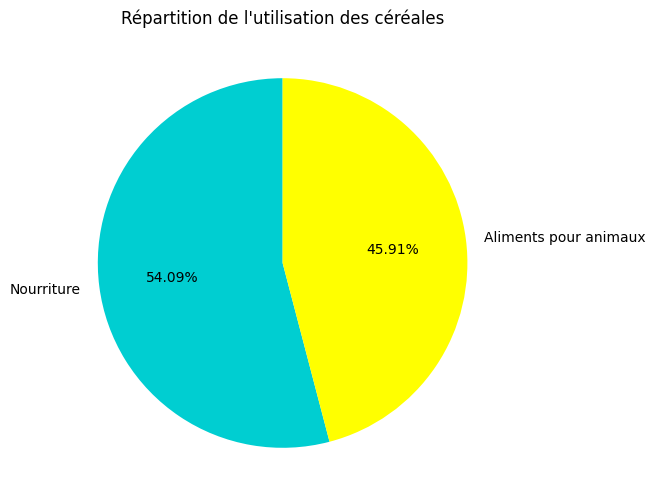

In [ ]:
# définir les données du diagramme circulaire
labels = ['Nourriture', 'Aliments pour animaux']
sizes = [proportion_nourriture, proportion_animaux]  # utiliser des proportions déjà calculées
colors = ['DarkTurquoise', 'yellow']  # définir les couleurs de chaque segment

# déterminer la taille et la configuration du diagramme circulaire
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)

# создание функции для отображения процентов с метками на сегментах
def func(pct, allvalues):
    absolute = int(pct/100.*sum(allvalues))
    return f"{labels[allvalues.index(absolute)]}\n{pct:.2f}%"

# nommer le graphique
plt.title('Répartition de l\'utilisation des céréales')

# afficher le graphique
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [ ]:
# vérifier le contenu d'un dataframe existant avec les données requises
print(pop_sousnutr_2017[['Zone', 'Population', 'Proportion']])


                      Zone  Population  Proportion
0              Afghanistan    36296113          29
1           Afrique du Sud    57009756           5
2                  Albanie     2884169           3
3                  Algérie    41389189           3
4                Allemagne    82658409           0
..                     ...         ...         ...
198  États-Unis d'Amérique   325084756           0
199               Éthiopie   106399924          20
200              Îles Cook       17507           0
201          Îles Marshall       58058           0
202           Îles Salomon      636039           0

[203 rows x 3 columns]


In [ ]:
# Trier les données par ordre décroissant de "Proportion" et sélectionner les 20 premières lignes
#  sort_values(by='Proportion', ascending=False) - trie le DataFrame par 'Proportion' de la valeur la plus élevée à la valeur la plus basse
# head(10) renvoie les 20 premières lignes du DataFrame trié
top_10_sousnutr = pop_sousnutr_2017.sort_values(by='Proportion', ascending=False).head(10)

# Résultats pour les 20 pays où la proportion de sous-alimentation est la plus élevée
print(top_10_sousnutr[['Zone', 'Population', 'Proportion']])

                                           Zone  Population  Proportion
72                                        Haïti    10982366          48
151  République populaire démocratique de Corée    25429825          47
99                                   Madagascar    25570512          41
95                                      Libéria     4702226          38
174                                       Tchad    15016753          38
91                                      Lesotho     2091534          37
143                                      Rwanda    11980961          35
112                                  Mozambique    28649018          33
177                                 Timor-Leste     1243258          32
0                                   Afghanistan    36296113          29


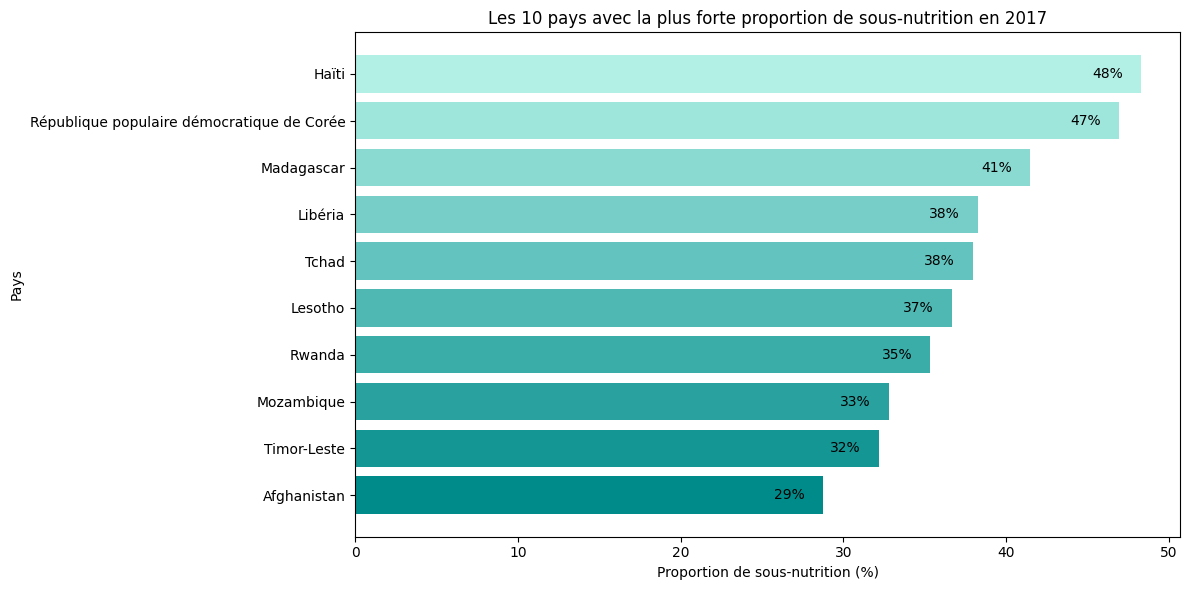

In [ ]:
# définir une variable pour la visualisation + ne laisser que les colonnes nécessaires
top_10_sousnutrition = top_10_sousnutr[['Zone', 'Proportion']]

# создать палитру из 10 оттенков 'DarkTurquoise'
from matplotlib.colors import LinearSegmentedColormap
colors = LinearSegmentedColormap.from_list('custom_turquoise', ['#b2f0e6', '#008b8b'], N=10)
color_values = colors(np.linspace(0, 1, len(top_10_sousnutrition)))

# déterminer la taille du graphique
plt.figure(figsize=(12, 6))

# créer un diagramme en barres + déterminer la couleur
bars = plt.barh(top_10_sousnutrition['Zone'], top_10_sousnutrition['Proportion'], color=color_values)

# ajouter des légendes aux axes et aux graphiques
plt.xlabel('Proportion de sous-nutrition (%)')
plt.ylabel('Pays')
plt.title('Les 10 pays avec la plus forte proportion de sous-nutrition en 2017')

# ajouter des valeurs en pourcentage aux colonnes; 'for bar in bars' : une boucle for qui parcourt chaque élément de 'bars'
# bars est un objet créé par la fonction plt.barh() lorsque j'ai dessiné les barres horizontales sur le graphique. Chaque élément de bars représente une barre différente sur le graphique
# méthode get_width() renvoie la largeur de chaque colonne - dans ce cas est le pourcentage de sous-nutrition (de la colonne Proportion)
# méthode get_y() renvoie la coordonnée de départ d'une colonne sur l'axe des ordonnées. Il s'agit de la position à laquelle cette colonne commence sur l'axe Y (hauteur sur l'axe vertical)
# méthode get_height() renvoie la hauteur d'une colonne ; dans un diagramme à barres horizontal, la hauteur correspond à l'épaisseur de la colonne sur l'axe vertical
# plt.text(x, y, s, va='centre') - fonction permettant d'ajouter du texte au graphique ; s: la chaîne de texte à afficher
# f'{bar.get_width() :.0f}%', pour que le texte affiche la valeur de la largeur de la colonne (pourcentage de sous-utilisation) et y ajoute un signe de pourcentage (%).

for bar in bars:
    plt.text(bar.get_width() - 3, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.0f}%', va='center')

# inverser l'axe des Y pour que les valeurs les plus élevées soient en haut de l'échelle
plt.gca().invert_yaxis()


plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire 2013-2016</h3>
</div>

In [ ]:
# filtrer les données par année de 2013 à 2916 inclus
filtered_data = aide_alimentaire[(aide_alimentaire['Année'] >= 2013) & (aide_alimentaire['Année'] <= 2016)]
filtered_data

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000
...,...,...,...,...
1470,Zimbabwe,2015,Mélanges et préparations,96000
1471,Zimbabwe,2013,Non-céréales,5022000
1472,Zimbabwe,2014,Non-céréales,2310000
1473,Zimbabwe,2015,Non-céréales,306000


In [ ]:
# convertir les kilogrammes en milliers de tonnes pour une meilleure représentation graphique
filtered_data['Valeur'] = filtered_data['Valeur'].astype(float) / 1000000
filtered_data

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,1
1,Afghanistan,2014,Autres non-céréales,0
2,Afghanistan,2013,Blé et Farin,39
3,Afghanistan,2014,Blé et Farin,15
4,Afghanistan,2013,Céréales,41
...,...,...,...,...
1470,Zimbabwe,2015,Mélanges et préparations,0
1471,Zimbabwe,2013,Non-céréales,5
1472,Zimbabwe,2014,Non-céréales,2
1473,Zimbabwe,2015,Non-céréales,0


In [ ]:
# calcul du total de l'aide alimentaire par pays
# as_index=False - il est important que le résultat n'utilise pas la colonne "Zone" comme index. Par conséquent, la colonne "Zone" restera une colonne
grouped_data = filtered_data.groupby('Zone', as_index=False)['Valeur'].sum()
grouped_data

,Zone,Valeur
0,Afghanistan,185
1,Algérie,81
2,Angola,5
3,Bangladesh,348
4,Bhoutan,3
...,...,...
71,Zambie,3
72,Zimbabwe,63
73,Égypte,1
74,Équateur,1


In [ ]:
# afficher après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
top_10_countries = grouped_data.sort_values(by='Valeur', ascending=False).head(10)
print(top_10_countries)

                                Zone  Valeur
50         République arabe syrienne    1859
75                          Éthiopie    1381
70                             Yémen    1206
61                     Soudan du Sud     695
60                            Soudan     670
30                             Kenya     553
3                         Bangladesh     348
59                           Somalie     293
53  République démocratique du Congo     289
43                             Niger     276


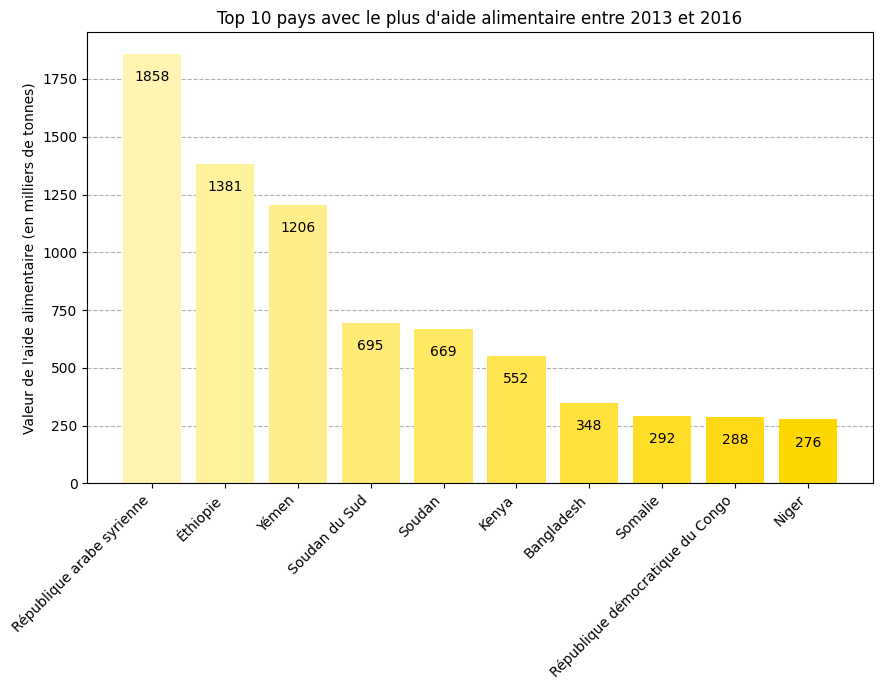

In [ ]:
# ajouter une classe de la bibliothèque Matplotlib qui permet de créer une palette de gradients qui passe d'une couleur à l'autre
from matplotlib.colors import LinearSegmentedColormap

# créer une palette de 10 tons de jaune
colors = LinearSegmentedColormap.from_list('yellow', ['#fff5b1', '#FFD700'], N=10)
color_values = colors(np.linspace(0, 1, len(top_10_countries)))

# prédéfinir les données pour la visualisation
labels = top_10_countries['Zone']
values = top_10_countries['Valeur']
color = color_values  # définir les couleurs de dataviz

# créer une figure et des axes
fig, ax = plt.subplots(figsize=(9, 7))

# construire diagramme à barres
ax.bar(labels, values, color=color_values)

# ajouter des légendes de valeur aux colonnes
for i, v in enumerate(values):
    ax.text(i, v - 130, f'{int(v)}', ha='center', va='bottom')

# ajouter des noms d'axes
ax.set_ylabel('Valeur de l\'aide alimentaire (en milliers de tonnes)')
ax.set_title('Top 10 pays avec le plus d\'aide alimentaire entre 2013 et 2016')

# tourner les étiquettes sur l'axe X de 45 degrés pour mieux afficher les noms longs
plt.xticks(rotation=45, ha='right')

# ajouter une grille horizontale au graphique et la régler sur la ligne pointillée
plt.grid(True, axis='y', linestyle='--')

# faire de la grille l'arrière-plan des colonnes du graphique
ax.set_axisbelow(True)

# afficher le graphique
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [ ]:
# Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année
# utiliser un dataframe déjà créé, filtré de 2013 à 2016
filtered_data

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,1
1,Afghanistan,2014,Autres non-céréales,0
2,Afghanistan,2013,Blé et Farin,39
3,Afghanistan,2014,Blé et Farin,15
4,Afghanistan,2013,Céréales,41
...,...,...,...,...
1470,Zimbabwe,2015,Mélanges et préparations,0
1471,Zimbabwe,2013,Non-céréales,5
1472,Zimbabwe,2014,Non-céréales,2
1473,Zimbabwe,2015,Non-céréales,0


In [ ]:
# regrouper les données par pays et par année
grouped_data2 = filtered_data.groupby(['Zone', 'Année']).sum()
grouped_data2

Produit  Valeur
Zone        Année                                                           
Afghanistan 2013   Autres non-céréalesBlé et FarinCéréalesFruits ...     128
            2014   Autres non-céréalesBlé et FarinCéréalesHuiles ...      57
Algérie     2013   Autres non-céréalesCéréalesCéréales Secondaire...      35
            2014   Autres non-céréalesCéréalesCéréales Secondaire...      19
            2015   Autres non-céréalesCéréalesCéréales Secondaire...      17
...                                                              ...     ...
Égypte      2013                      Fruits secs, totalNon-céréales       1
Équateur    2013   CéréalesHuiles végétalesLégumineuses Sèches,To...       1
Éthiopie    2013   Autres non-céréalesBlé et FarinBulgurFarEntCér...     591
            2014   Autres non-céréalesBlé et FarinBulgurFarEntCér...     587
            2015   Autres non-céréalesBlé et FarinCéréalesCéréale...     203

[228 rows x 2 columns]

In [ ]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
top_5_countries = filtered_data.groupby('Zone')['Valeur'].sum().sort_values(ascending=False).head(5).index.tolist()

In [ ]:
#On filtre sur le dataframe avec notre liste
filtered_top_5 = filtered_data[filtered_data['Zone'].isin(top_5_countries)]
filtered_top_5

,Zone,Année,Produit,Valeur
354,Éthiopie,2013,Autres non-céréales,0
355,Éthiopie,2014,Autres non-céréales,0
356,Éthiopie,2015,Autres non-céréales,0
357,Éthiopie,2013,Blé et Farin,181
358,Éthiopie,2014,Blé et Farin,179
...,...,...,...,...
1447,Yémen,2015,"Riz, total",2
1448,Yémen,2013,"Sucre, total",0
1449,Yémen,2014,"Sucre, total",0
1450,Yémen,2015,"Sucre, total",8


In [ ]:
# Affichage des pays avec l'aide alimentaire par année
result = filtered_top_5.groupby(['Zone', 'Année'])['Valeur'].sum().reset_index()
print(result)

                         Zone  Année  Valeur
0   République arabe syrienne   2013     564
1   République arabe syrienne   2014     652
2   République arabe syrienne   2015     525
3   République arabe syrienne   2016     119
4                      Soudan   2013     330
5                      Soudan   2014     322
6                      Soudan   2015      18
7               Soudan du Sud   2013     196
8               Soudan du Sud   2014     451
9               Soudan du Sud   2015      48
10                      Yémen   2013     265
11                      Yémen   2014     104
12                      Yémen   2015     372
13                      Yémen   2016     466
14                   Éthiopie   2013     591
15                   Éthiopie   2014     587
16                   Éthiopie   2015     203


In [ ]:
# Перевод значений в столбце 'Valeur' из килограммов в тысячи тонн
result['Valeur'] = result['Valeur'].astype(float) #/ 1000000

# Отобразим результат
print(result)


                         Zone  Année  Valeur
0   République arabe syrienne   2013     564
1   République arabe syrienne   2014     652
2   République arabe syrienne   2015     525
3   République arabe syrienne   2016     119
4                      Soudan   2013     330
5                      Soudan   2014     322
6                      Soudan   2015      18
7               Soudan du Sud   2013     196
8               Soudan du Sud   2014     451
9               Soudan du Sud   2015      48
10                      Yémen   2013     265
11                      Yémen   2014     104
12                      Yémen   2015     372
13                      Yémen   2016     466
14                   Éthiopie   2013     591
15                   Éthiopie   2014     587
16                   Éthiopie   2015     203


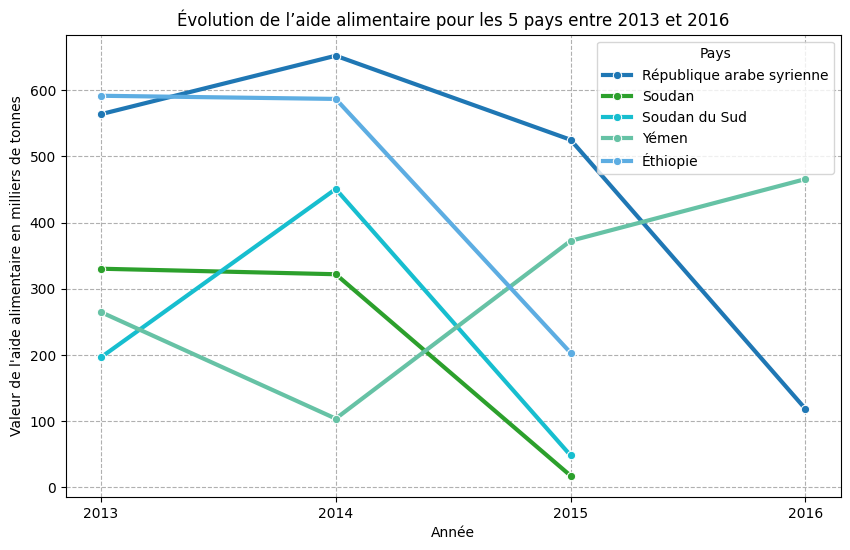

In [ ]:
import seaborn as sns
palette = ["#1f77b4", "#2ca02c", "#17becf", "#66c2a5", "#5dade2"]

# créer graphique
plt.figure(figsize=(10, 6))
sns.lineplot(data=result, x='Année', y='Valeur', hue='Zone', palette=palette, marker="o", linewidth=3)

# définir les noms des axes et des lignes, la grille du tableau
plt.title("Évolution de l’aide alimentaire pour les 5 pays entre 2013 et 2016")
plt.xlabel("Année")
plt.ylabel("Valeur de l'aide alimentaire en milliers de tonnes")
plt.xticks([2013, 2014, 2015, 2016])
plt.legend(title="Pays")

# activer la grille graphique et la rendre pointillée
plt.grid(True, linestyle='--')

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [ ]:
dispo_alimentaire

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,calculated_dispo_interieure
0,Afghanistan,Abats Comestible,animale,0,0,5,2,0,1,53000000,0,0,53000000,0,53000000,0,0,0,53000000
1,Afghanistan,"Agrumes, Autres",vegetale,0,0,1,1,0,0,41000000,2000000,40000000,39000000,2000000,3000000,0,0,0,41000000
2,Afghanistan,Aliments pour enfants,vegetale,0,0,1,0,0,0,2000000,0,2000000,2000000,0,0,0,0,0,2000000
3,Afghanistan,Ananas,vegetale,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,Afghanistan,Bananes,vegetale,0,0,4,3,0,0,82000000,0,82000000,82000000,0,0,0,0,0,82000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15600,Îles Salomon,Viande de Suides,animale,0,0,45,5,4,1,3000000,0,0,3000000,0,2000000,0,0,0,2000000
15601,Îles Salomon,Viande de Volailles,animale,0,0,11,3,1,1,2000000,0,2000000,2000000,0,0,0,0,0,2000000
15602,Îles Salomon,"Viande, Autre",animale,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
15603,Îles Salomon,Vin,vegetale,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
#Calcul de la disponibilité en kcal par personne par jour par pays

# sélectionner les données nécessaires au calcul (dans ce cas, « Zone » - pays, « Disponibilité alimentaire » - disponibilité en Kcal/personne/jour)
dispo_kcal = dispo_alimentaire[['Zone', 'Disponibilité alimentaire (Kcal/personne/jour)']]

# regrouper par pays et calculer la disponibilité totale de tous les aliments par personne et par jour (en kilocalories)
dispo_kcal_grouped = dispo_kcal.groupby('Zone', as_index=False)['Disponibilité alimentaire (Kcal/personne/jour)'].sum()

# renommer colonne pour une meilleure lisibilité
dispo_kcal_grouped.rename(columns={'Disponibilité alimentaire (Kcal/personne/jour)': 'Total_kcal_par_personne_par_jour'}, inplace=True)

# afficher le résultat
dispo_kcal_grouped


,Zone,Total_kcal_par_personne_par_jour
0,Afghanistan,2087
1,Afrique du Sud,3020
2,Albanie,3188
3,Algérie,3293
4,Allemagne,3503
...,...,...
169,Émirats arabes unis,3275
170,Équateur,2346
171,États-Unis d'Amérique,3682
172,Éthiopie,2129


In [ ]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne
print(dispo_kcal_grouped.sort_values(by='Total_kcal_par_personne_par_jour', ascending=True).head(10))

                                           Zone  \
128                   République centrafricaine   
166                                      Zambie   
91                                   Madagascar   
0                                   Afghanistan   
65                                        Haïti   
133  République populaire démocratique de Corée   
151                                       Tchad   
167                                    Zimbabwe   
114                                     Ouganda   
154                                 Timor-Leste   

     Total_kcal_par_personne_par_jour  
128                              1879  
166                              1924  
91                               2056  
0                                2087  
65                               2089  
133                              2093  
151                              2109  
167                              2113  
114                              2126  
154                              2129 

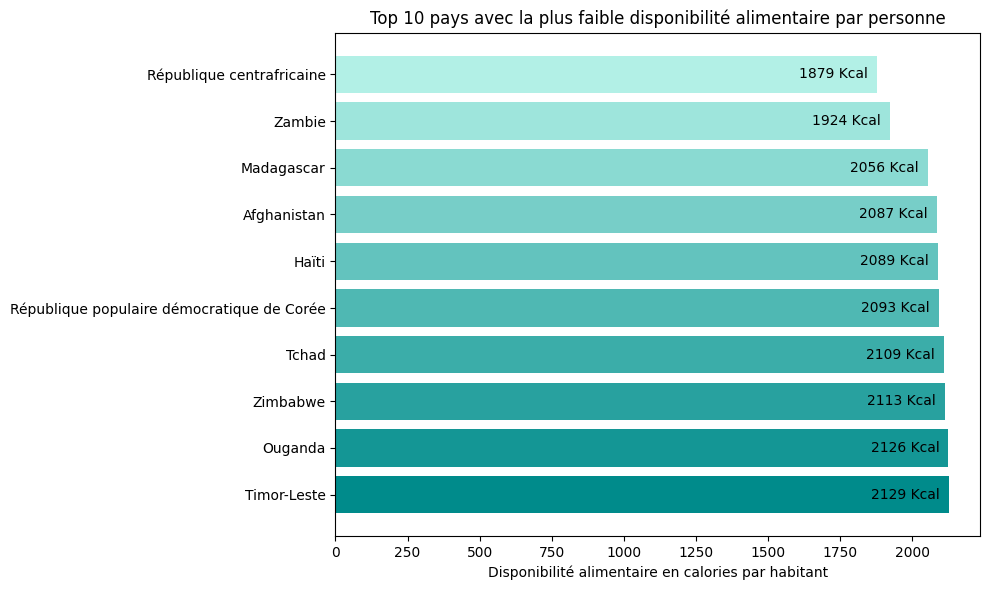

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

# créer une palette de 10 tons de turquoise (du plus clair au plus foncé)
# dans ce cas, la fonction LinearSegmentedColormap crée un gradient du turquoise clair au turquoise foncé
colors = LinearSegmentedColormap.from_list('custom_biruz', ['#b2f0e6', '#008b8b'], N=10)

# prédéfinir les données pour la visualisation
top_10_lowest = dispo_kcal_grouped.sort_values(by='Total_kcal_par_personne_par_jour').head(10)
labels = top_10_lowest['Zone']
values = top_10_lowest['Total_kcal_par_personne_par_jour']

# créer une figure et des axes
fig, ax = plt.subplots(figsize=(10, 6))

# créer un diagramme à barres horizontales
ax.barh(labels, values, color=colors(np.linspace(0, 1, len(labels))))

# ajouter des légendes aux colonnes à l'aide d'une boucle
for i, v in enumerate(values):
    ax.text(v - 270,  # déplacer la valeur de 270 unités vers la gauche pour qu'elle se trouve à l'intérieur de la colonne
            i,  # # est utilisé pour positionner le texte sur l'axe Y. Dans ce cas, il s'agit de la position sur l'axe Y où le texte sera placé
            f'{v:.0f} Kcal',  # supprimer le point décimal pour obtenir une valeur entière, et ajouter le texte
            color='black',
            va='center')  # alignement vertical de la valeur par rapport au centre

# personnaliser les noms des axes
ax.set_xlabel('Disponibilité alimentaire en calories par habitant')
ax.set_title('Top 10 pays avec la plus faible disponibilité alimentaire par personne')

# inverser l'axe des Y en plaçant les plus petites valeurs en haut de l'échelle
ax.invert_yaxis()

# afficher le graphique
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [ ]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne
print(dispo_kcal_grouped.sort_values(by='Total_kcal_par_personne_par_jour', ascending=False).head(10))

                      Zone  Total_kcal_par_personne_par_jour
11                Autriche                              3770
16                Belgique                              3737
159                Turquie                              3708
171  États-Unis d'Amérique                              3682
74                  Israël                              3610
72                 Irlande                              3602
75                  Italie                              3578
89              Luxembourg                              3540
168                 Égypte                              3518
4                Allemagne                              3503


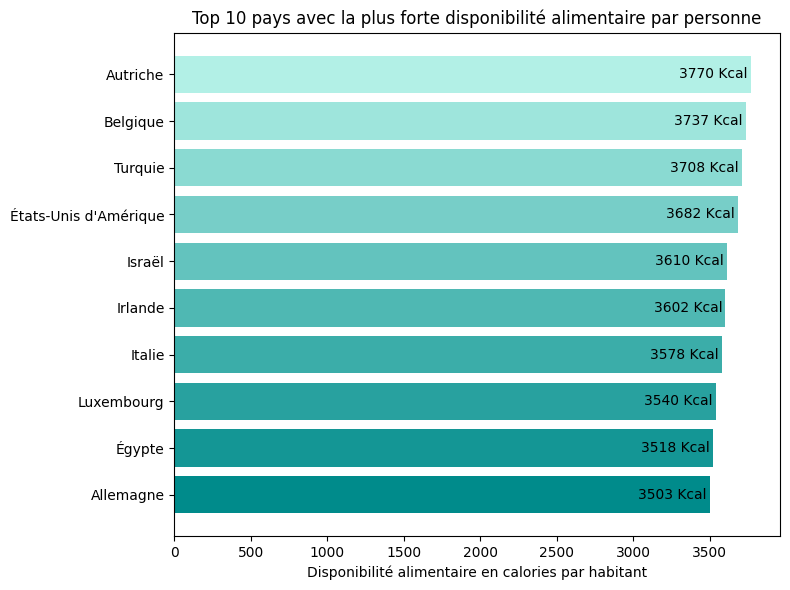

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

# créer une palette de 10 tons de turquoise (du plus clair au plus foncé)
# dans ce cas, la fonction LinearSegmentedColormap crée un gradient du turquoise clair au turquoise foncé
colors = LinearSegmentedColormap.from_list('custom_biruz', ['#b2f0e6', '#008b8b'], N=10)

# prédéfinir les données pour la visualisation
top_10_highest = dispo_kcal_grouped.sort_values(by='Total_kcal_par_personne_par_jour', ascending=False).head(10)
labels = top_10_highest['Zone']
values = top_10_highest['Total_kcal_par_personne_par_jour']

# créer une figure et des axes
fig, ax = plt.subplots(figsize=(8, 6))

# créer un diagramme à barres horizontales
ax.barh(labels, values, color=colors(np.linspace(0, 1, len(labels))))

# ajouter des légendes aux colonnes à l'aide d'une boucle
for i, v in enumerate(values):
    ax.text(v - 470,  # déplacer la valeur de 470 unités vers la gauche pour qu'elle se trouve à l'intérieur de la colonne
            i,  # est utilisé pour positionner le texte sur l'axe Y. Dans ce cas, il s'agit de la position sur l'axe Y où le texte sera placé
            f'{v:.0f} Kcal',  # supprimer le point décimal pour obtenir une valeur entière, et ajouter le texte
            color='black',
            va='center') # alignement vertical de la valeur par rapport au centre

# personnaliser les noms des axes
ax.set_xlabel('Disponibilité alimentaire en calories par habitant')
ax.set_title('Top 10 pays avec la plus forte disponibilité alimentaire par personne')

# inverser l'axe des Y en plaçant les plus petites valeurs en haut de l'échelle
ax.invert_yaxis()

# afficher le graphique
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [ ]:
# afficher les colonnes des deux tableaux sources
print(sous_nutrition.columns)
print(population.columns)

Index(['Zone', 'sous_nutrition', 'Année1', 'Année3', 'Année2'], dtype='object')
Index(['Zone', 'Année', 'Population'], dtype='object')


In [ ]:
# sélectionner les données sur la sous-nutrition en Thaïlande
sous_nutrition_thailand = sous_nutrition[sous_nutrition['Zone'] == 'Thaïlande'][['Zone', 'sous_nutrition']]
sous_nutrition_thailand

,Zone,sous_nutrition
1110,Thaïlande,6200000
1111,Thaïlande,6000000
1112,Thaïlande,5900000
1113,Thaïlande,6000000
1114,Thaïlande,6200000
1115,Thaïlande,6500000


In [ ]:
# sélectionner les données sur la population en Thaïlande
population_thailand = population[population['Zone'] == 'Thaïlande'][['Zone', 'Population']]
population_thailand

,Zone,Population
1308,Thaïlande,68144518
1309,Thaïlande,68438746
1310,Thaïlande,68714511
1311,Thaïlande,68971308
1312,Thaïlande,69209810
1313,Thaïlande,69428453


In [ ]:
#Calcul de la sous nutrition en Thaïlande

# fusionner des données dans le champ Zone
merged_data = pd.merge(sous_nutrition_thailand, population_thailand, on='Zone')

# calculer la valeur moyenne de 'sous_nutrition' et 'Population' + arrondir à un nombre entier
mean_sous_nutrition = round(merged_data['sous_nutrition'].mean())
mean_population = round(merged_data['Population'].mean())

# calculer la part de sous_nutrition de la population
part_sous_nutrition = (mean_sous_nutrition / mean_population) * 100

# afficher les résultats
print(f"La moyenne de la population sous-nourrie est de {mean_sous_nutrition} personnes !")
print(f"Dans le même temps, la population moyenne du pays pendant cette période est de {mean_population} personnes...")
print(f"Ainsi, {part_sous_nutrition:.2f}% de la population du pays souffre de sous-nutrition !")

La moyenne de la population sous-nourrie est de 6133333 personnes !
Dans le même temps, la population moyenne du pays pendant cette période est de 68817891 personnes...
Ainsi, 8.91% de la population du pays souffre de sous-nutrition !


In [ ]:
# comparer et analyser les volumes de production et d'exportation de manioc en Thaïlande

# sélectionner les données pour la Thaïlande et le produit Manioc dans la table dispo_alimentaire
manioc_thailand = dispo_alimentaire[(dispo_alimentaire['Zone'] == 'Thaïlande') &
                                    (dispo_alimentaire['Produit'] == 'Manioc')]

# extraire les colonnes cibles Production et Exportations - Quantité
production = round(manioc_thailand['Production'].sum() / 1000)  # sommer la valeur de la colonne et la convertir en tonnes
exportation = round(manioc_thailand['Exportations - Quantité'].sum() / 1000)  # sommer la valeur de la colonne et la convertir en tonnes

# afficher les résultats des calculs
print(f"La production totale de manioc en Thaïlande est de {production} tonnes")
print(f"Le volume total des exportations de manioc de la Thaïlande est de {exportation} tonnes")

# calculer le ratio exportations/production
if production > 0:  #  la boucle vérifie qu'il n'y a pas de division par zéro
    export_to_production_ratio = round((exportation / production) * 100)
    print(f"Pourcentage de manioc produit exporté de Thaïlande : {export_to_production_ratio}%")
else:
    print(" Aucune donnée sur la production du produit.")

La production totale de manioc en Thaïlande est de 30228000 tonnes
Le volume total des exportations de manioc de la Thaïlande est de 25214000 tonnes
Pourcentage de manioc produit exporté de Thaïlande : 83%


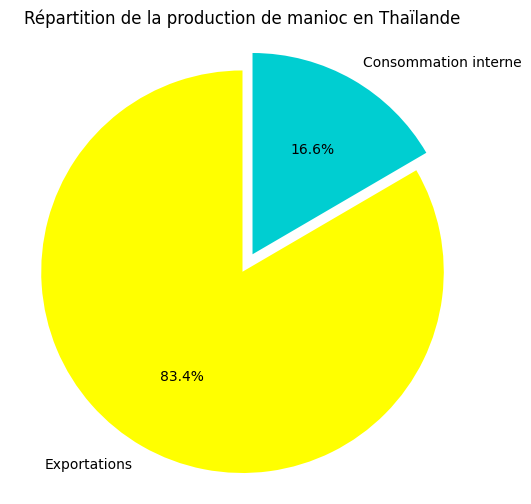

In [ ]:
import matplotlib.pyplot as plt

# prédéfinir les valeurs des variables pour la visualisation
labels = ['Exportations', 'Consommation interne']  # exportations et consommation intérieure
sizes = [exportation, production - exportation]  # des exportations et le reste
colors = ['yellow', 'DarkTurquoise']
explode = (0.1, 0)  # déplacer la part de la consommation intérieure

# créer un diagramme circulaire et en spécifier la taille et les paramètres
plt.figure(figsize=(6, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.axis('equal')  # paramètre utilisé pour une forme de visualisation fluide

# ajouter un en-tête
plt.title("Répartition de la production de manioc en Thaïlande")

# afficher le diagramme
plt.show()

In [ ]:
# calculer la disponibilité du manioc par habitant en Thaïlande au cours de la période couverte

# calculer la quantité de manioc restant pour l'usage interne
consommation_interne = (production * 1000) - (exportation * 1000)  # convertir tonnes en kilogrammes

# calculer la quantité de manioc par personne en Thaïlande par an
manioc_per_person = round(consommation_interne / mean_population)

# calculer la quantité de manioc en grammes par habitant et par jour
manioc_per_person_per_day = round((manioc_per_person * 1000) / 365)  # convertir en grammes et diviser par le nombre de jours de l'année

# afficher le résultat
print(f"La quantité moyenne de manioc calculée pour la période étudiée n'est que de {manioc_per_person} kilogrammes disponibles par habitant de Thaïlande et par an...")
print(f"Autrement dit, chaque Thaïlandais ne dispose que de {manioc_per_person_per_day} grammes de manioc par jour.")

La quantité moyenne de manioc calculée pour la période étudiée n'est que de 73 kilogrammes disponibles par habitant de Thaïlande et par an...
Autrement dit, chaque Thaïlandais ne dispose que de 200 grammes de manioc par jour.


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

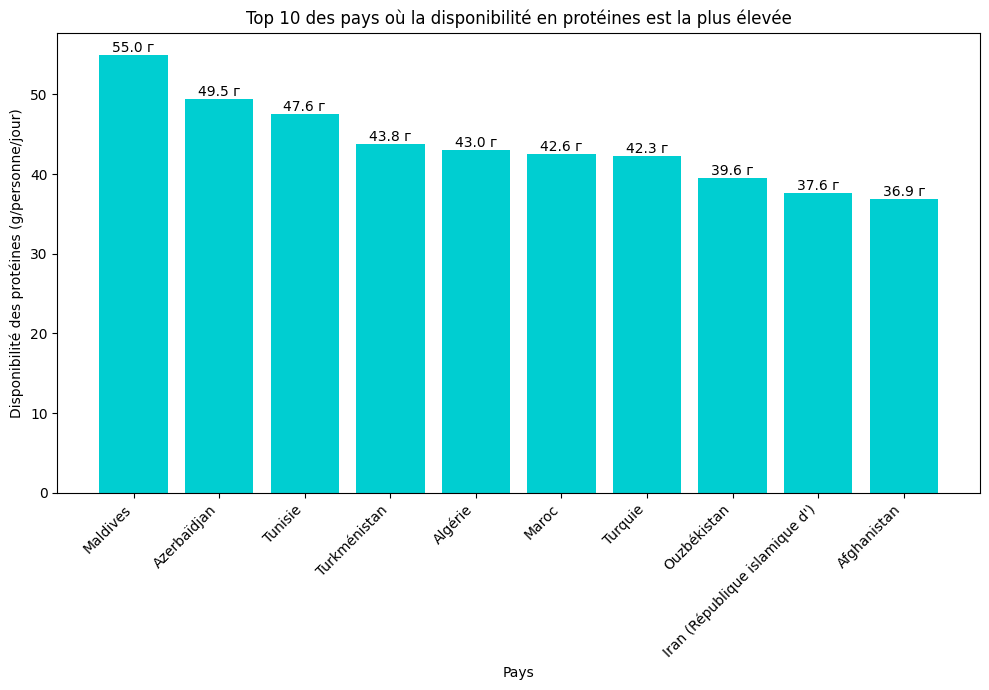

In [ ]:
# sélectionner les colonnes nécessaires dans la table dispo_alimentaire
protein = dispo_alimentaire[['Zone', 'Disponibilité de protéines en quantité (g/personne/jour)']]

# trier les données par ordre décroissant de disponibilité des protéines
protein_sorted = protein.sort_values(by='Disponibilité de protéines en quantité (g/personne/jour)', ascending=False)

# sélectionner les 10 pays où la disponibilité en protéines est la plus élevée
top_10_countries = protein_sorted.head(10)

# définir les dimensions et les axes de visualisation
fig, ax = plt.subplots(figsize=(10, 7))

# créer un diagramme à barres
bars = ax.bar(top_10_countries['Zone'], top_10_countries['Disponibilité de protéines en quantité (g/personne/jour)'], color='DarkTurquoise')

# ajouter des légendes d'axes
ax.set_xlabel('Pays')
ax.set_ylabel('Disponibilité des protéines (g/personne/jour)')
ax.set_title('Top 10 des pays où la disponibilité en protéines est la plus élevée')

# ajouter des légendes d'axes de barres
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{bar.get_height():.1f} г',
            ha='center', va='bottom', fontsize=10)

# tourner les marques sur l'axe X
plt.xticks(rotation=45, ha='right')

# afficher le graphique
plt.tight_layout()
plt.show()
